# 03 · Look-ahead K (Exp3) — *K=0 vs K=5 within each method*

Research question (i): does anticipating K future turns when scoring help? K0-vs-K5 trajectory overlay
→ paired K0−K5 statistics → K-effect on the PTO preference margin. **The LA5 arms are still thin** —
treat this notebook as preliminary until the K=5 sweep fills in.

In [1]:
import sys, os; sys.path.insert(0, os.path.abspath("."))           # cwd = eda/ -> `import exp3`
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
pd.set_option("display.width", 185, "display.max_columns", 50)
import exp3
from exp3 import stats, behavior, training, pref, figures, plots
S = exp3.notebook_setup()      # S.ARMS, S.SCORES, S.PALETTE, S.METRICS, S.ORACLE_NOISE, S.RESULTS_DIR

arms on disk: [('PTO_LA0', 11), ('PTO_LA5', 6), ('GRPO_LA0', 6), ('GRPO_LA5', 2)]
scores_long: (16128, 19) | arms scored: ['GRPO_LA0', 'GRPO_LA5', 'PTO_LA0', 'PTO_LA5']
exports -> C:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\eda\results


## 0 · Data-availability banner

In [2]:
def common_iters(a, b):
    return sorted(set(S.SCORES[S.SCORES.arm == a].iteration) & set(S.SCORES[S.SCORES.arm == b].iteration))
for method in ["PTO", "GRPO"]:
    a0, a5 = f"{method}_LA0", f"{method}_LA5"
    ci = common_iters(a0, a5) if a5 in set(S.SCORES.arm) else []
    tag = "" if len(ci) >= 2 else "   <-- thin: K comparison is preliminary"
    print(f"{method}: K0 & K5 both-scored iters = {ci}{tag}")

PTO: K0 & K5 both-scored iters = [0, 1, 2, 3, 4]
GRPO: K0 & K5 both-scored iters = [0, 1]


## 1 · K0 vs K5 trajectory overlay (per method)

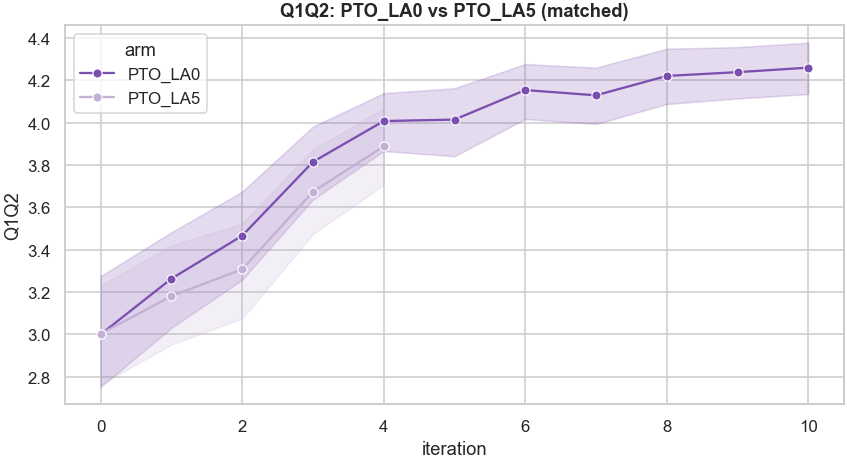

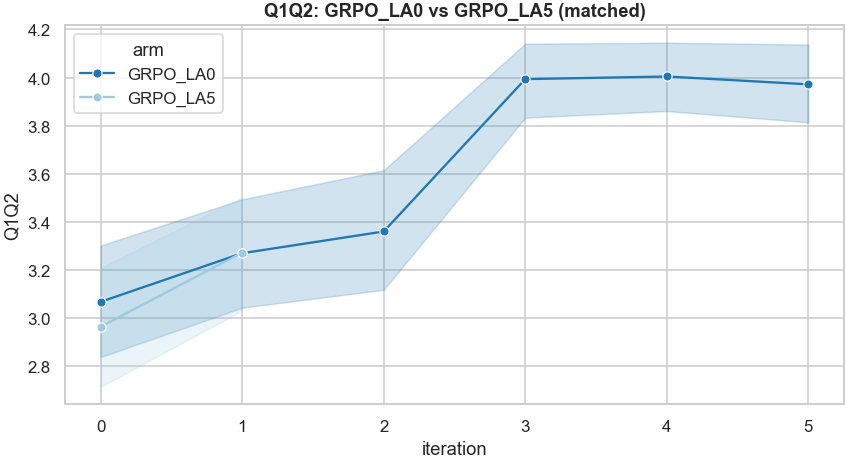

In [3]:
for method in ["PTO", "GRPO"]:
    fig = plots.method_contrast_overlay(S.SCORES, "Q1Q2", pair=(f"{method}_LA0", f"{method}_LA5"), palette=S.PALETTE)
    if fig is None:
        print(f"{method}: LA5 not scored yet."); continue
    exp3.save_fig(fig, f"{method}_K0_vs_K5_Q1Q2", caption=f"{method} K=0 vs K=5 Q1+Q2 trajectory (mean +/- 95% CI).")
    plt.show()

## 2 · Paired K0 − K5 statistics

In [4]:
for method in ["PTO", "GRPO"]:
    CMP = stats.paired_k_comparison(S.SCORES, method)
    if CMP.empty:
        print(f"{method}: K0-vs-K5 not comparable yet (LA5 under-scored)."); continue
    view = CMP[["iteration", "metric", "mean_delta", "dz", "p_holm"]].round(4)
    print(f"\n=== {method}: LA0 - LA5 (K0 - K5; + => K0 higher) ==="); display(view)
    exp3.save_table(view, f"{method}_K0_vs_K5_paired", caption=f"{method} K0 - K5 at matched iterations; persona-paired Wilcoxon + dz + Holm.")


=== PTO: LA0 - LA5 (K0 - K5; + => K0 higher) ===


,iteration,metric,mean_delta,dz,p_holm
0,0,Q1Q2,-0.0029,-0.0028,1.0000
1,0,WAI-SR,0.0252,0.0353,1.0000
2,0,CSQ-8,0.0456,0.0676,1.0000
3,0,MI-SAT,0.0156,0.0192,1.0000
4,0,MITI,-0.0156,-0.0172,1.0000
5,0,Q1,-0.0229,-0.0217,1.0000
6,0,Q2,0.0172,0.0155,1.0000
7,1,Q1Q2,0.0828,0.0931,1.0000
8,1,WAI-SR,-0.0295,-0.0452,1.0000
9,1,CSQ-8,-0.0104,-0.0150,1.0000



=== GRPO: LA0 - LA5 (K0 - K5; + => K0 higher) ===


,iteration,metric,mean_delta,dz,p_holm
0,0,Q1Q2,0.1036,0.1148,1.0
1,0,WAI-SR,0.0330,0.0509,1.0
2,0,CSQ-8,0.0065,0.0112,1.0
3,0,MI-SAT,0.0365,0.0444,1.0
4,0,MITI,0.1042,0.1280,1.0
5,0,Q1,0.1104,0.1196,1.0
6,0,Q2,0.0968,0.1032,1.0
7,1,Q1Q2,-0.0025,-0.0028,1.0
8,1,WAI-SR,0.0122,0.0178,1.0
9,1,CSQ-8,0.0807,0.1154,1.0


## 3 · K-effect on the PTO preference margin

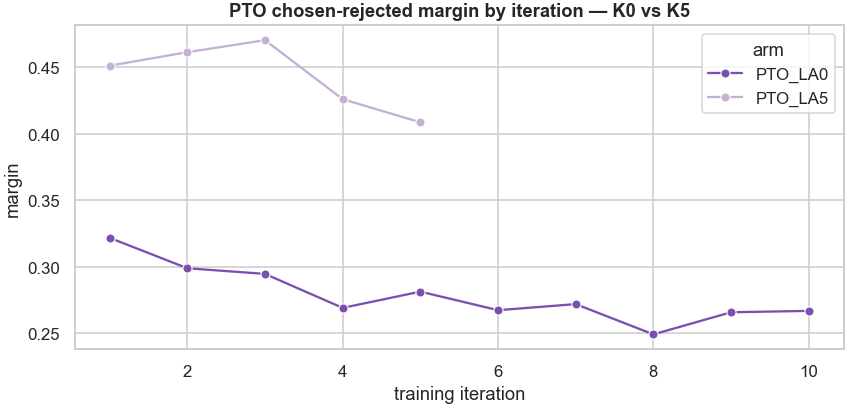

In [5]:
pp = training.load_pref_pairs([a for a in S.ARMS if a.method == "PTO"])
if not pp.empty and "margin" in pp.columns:
    g = pp.groupby(["arm", "train_iter"])["margin"].mean().reset_index()
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.lineplot(g, x="train_iter", y="margin", hue="arm", marker="o",
                 palette=figures.arm_palette(sorted(g.arm.unique())), ax=ax)
    ax.set_title("PTO chosen-rejected margin by iteration — K0 vs K5"); ax.set_xlabel("training iteration")
    fig.tight_layout(); plt.show()
else:
    print("No PTO preference pairs available yet.")

## 4 · Takeaways
- With the current data the K=5 arms have too few scored iterations for a confident K verdict — §0 prints
  exactly how many matched points exist.
- The look-ahead lever is **purely a scoring-context change** (same loss), so any K effect should show up
  identically in PTO (§2) and GRPO (§2) and in the preference margin (§3).
- _(Revisit once the K=5 sweep completes ~10 iters.)_